## Homework 1: Gradient Descent

### Exercise 1: GD on a 1D Function

In [55]:
import numpy as np
import matplotlib.pyplot as plt


In [56]:
theta0 = 0.0
n_iters = 500
etas = [0.05, 0.2, 1.0]

# tolerance of gradient in GD (small values represents less distance from a stationary point)
tolL = .01

# tolerance of distance between current and next value of theta in GD
tol_theta = .01

In [57]:
def L(theta):
    return (theta - 3.0) ** 2 + 1.0


def grad_L(theta):
    return 2.0 * (theta - 3.0)    
    
def gradient_descent(theta0, eta, n_iters):
    # Store all iterates and corresponding loss values
    thetas = [theta0]
    losses = [L(theta0)]

    theta = theta0
    theta_prev = theta0

    for _ in range(n_iters):
        # Gradient descent step
        theta = theta - eta * grad_L(theta)

        thetas.append(theta)
        losses.append(L(theta))

        # stopping criteria
        if (np.linalg.norm(grad_L(theta)) < tolL) or \
           (np.linalg.norm(theta - theta_prev) < tol_theta):
            break

        theta_prev = theta

    return theta, np.array(thetas), np.array(losses)


In [58]:

# Plot the sequence of theta values on the real line
def plot_position_of_thetas(thetas, theta_star=3.0):
    plt.figure()
    plt.axhline(0.0)  # represents the real line
    plt.scatter(thetas, np.zeros_like(thetas),
                alpha=0.6, label="successive thetas")
    plt.scatter([theta_star], [0.0],
                color="red", label=f"solution at {theta_star:.2f}")
    plt.yticks([])
    plt.title("Position of Successive thetas")
    plt.legend()
    plt.tight_layout()


# Plot loss value as a function of iteration index
def plot_loss_vs_iteration(losses):
    plt.figure()
    plt.plot(range(len(losses)), losses)
    plt.title("Loss values vs Iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Loss value")
    plt.tight_layout()


# Plot the loss function and overlay the GD trajectory
def plot_loss_and_thetas(thetas, theta_star=3.0):
    # Define a grid that covers all visited thetas
    lo = min(thetas.min(), theta_star) - 2.0
    hi = max(thetas.max(), theta_star) + 2.0
    grid = np.linspace(lo, hi, 400)

    plt.figure()
    plt.plot(grid, L(grid), label="Loss")
    plt.scatter(thetas, L(thetas),
                alpha=0.6, label="successive thetas")
    plt.scatter([theta_star], [L(theta_star)],
                color="red", label=f"solution at {theta_star:.2f}")
    plt.title("Loss and Thetas")
    plt.xlabel("Theta")
    plt.ylabel("Loss value")
    plt.legend()
    plt.tight_layout()


def draw_plots(eta, losses, theta_star):
    plot_position_of_thetas(eta, theta_star)
    plot_loss_vs_iteration(losses)
    plot_loss_and_thetas(eta, theta_star)
    
    plt.show()


η = 0.05
theta_0 = 0.000000, theta_last = 2.916561
L(theta_0) = 10.000000, L(theta_last) = 1.006962


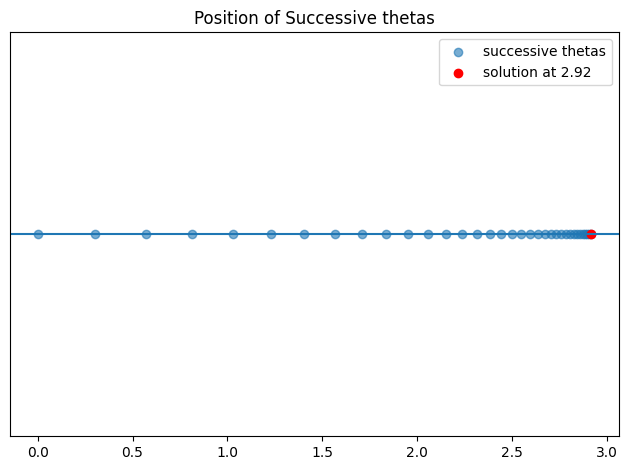

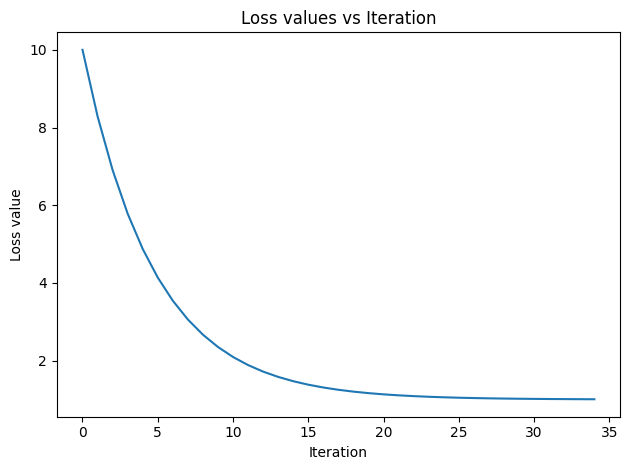

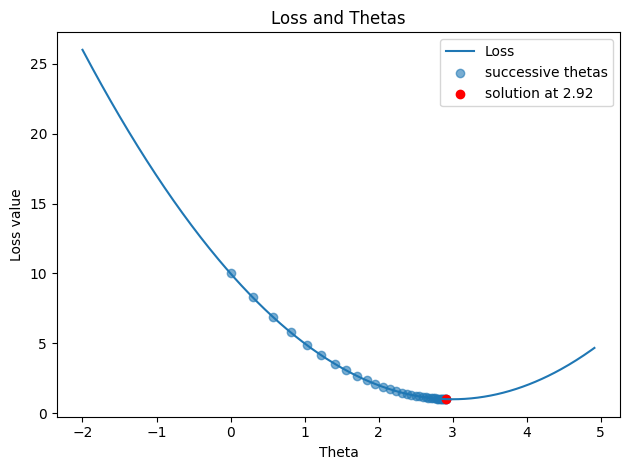


η = 0.2
theta_0 = 0.000000, theta_last = 2.989116
L(theta_0) = 10.000000, L(theta_last) = 1.000118


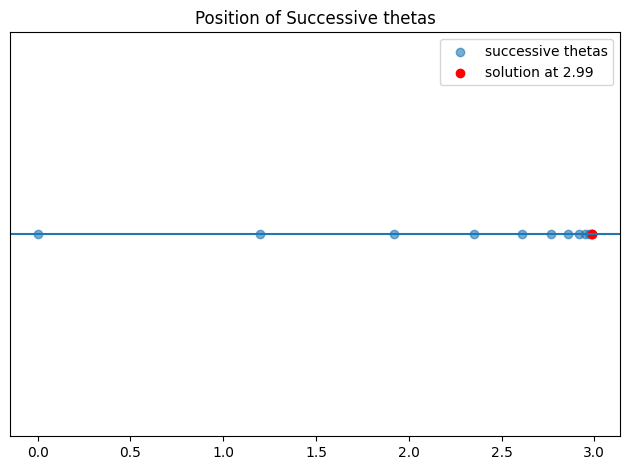

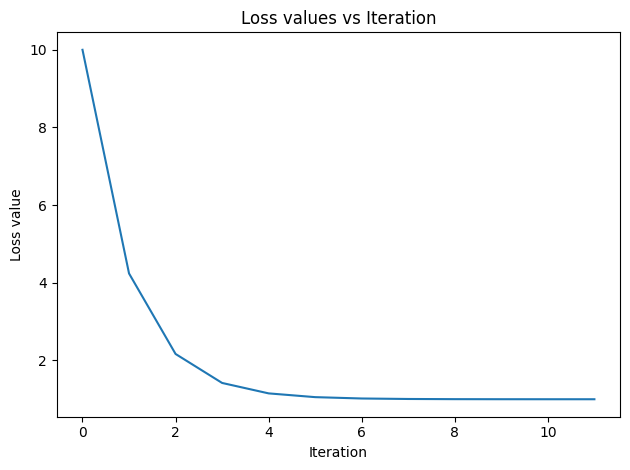

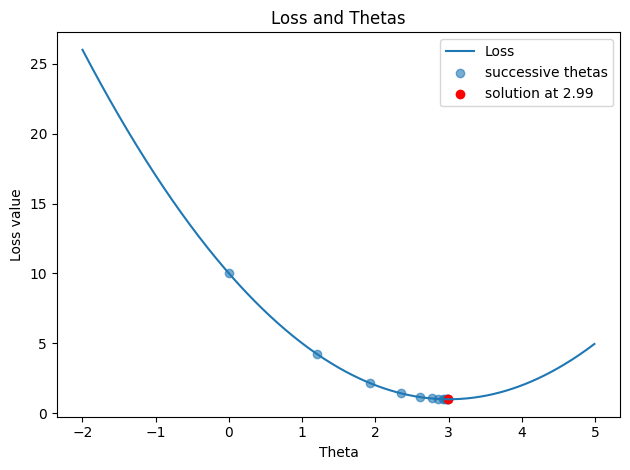


η = 1.0
theta_0 = 0.000000, theta_last = 0.000000
L(theta_0) = 10.000000, L(theta_last) = 10.000000


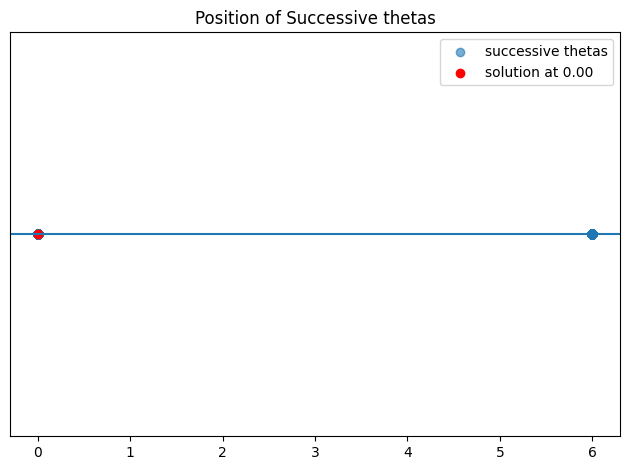

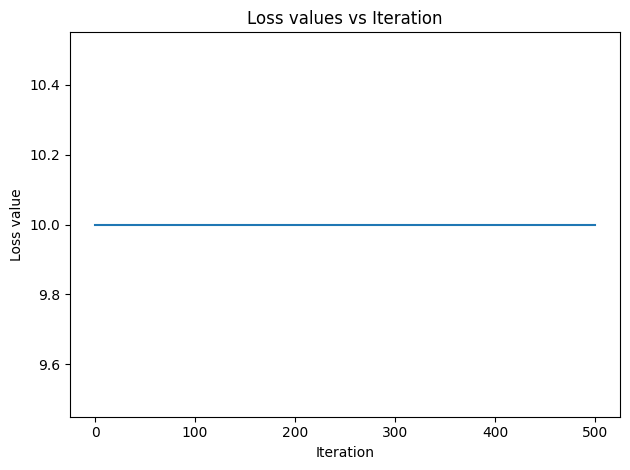

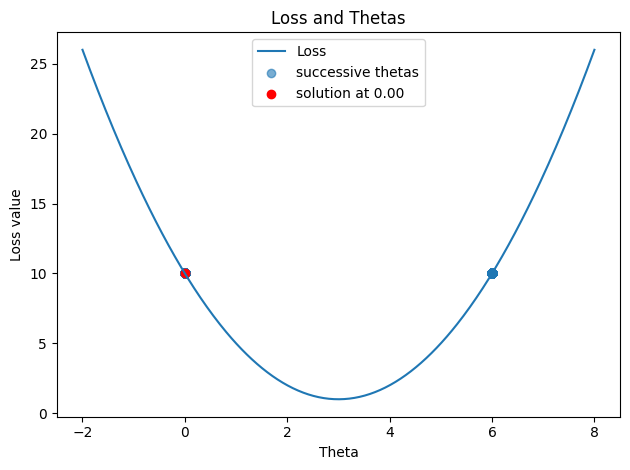

In [59]:
for eta in etas:
    theta_star, thetas, losses = gradient_descent(theta0, eta, n_iters)
    
    print(f"\nη = {eta}")
    print(f"theta_0 = {thetas[0]:.6f}, theta_last = {thetas[-1]:.6f}")
    print(f"L(theta_0) = {losses[0]:.6f}, L(theta_last) = {losses[-1]:.6f}")
    
    draw_plots(thetas, losses, theta_star)
